In [15]:
%load_ext autoreload
%autoreload 2
from EndEffectorPoseOptimizer import *
from JupyterVisualizer import  *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
optimizer = EndEffectorPoseOptimizer()

# 1. 데이터 선택

### 1.1. 스캔 데이터 선택

In [ ]:
# optimizer.load_scan_data('./data/PIPE NO.1_fill.ply')
# optimizer.load_scan_data('./data/PIPE NO.2_fill.ply')
optimizer.load_scan_data('./data/PIPE NO.3_fill.ply')
optimizer.load_scan_data('../../../sample/MERGED_SPOOL-004_0001_20260528T170812_mesh.ply')

### 선택된 스캔 데이터 가시화

Widget(value='<iframe src="http://localhost:59984/index.html?ui=P_0x1fa8b781390_4&reconnect=auto" class="pyvis…

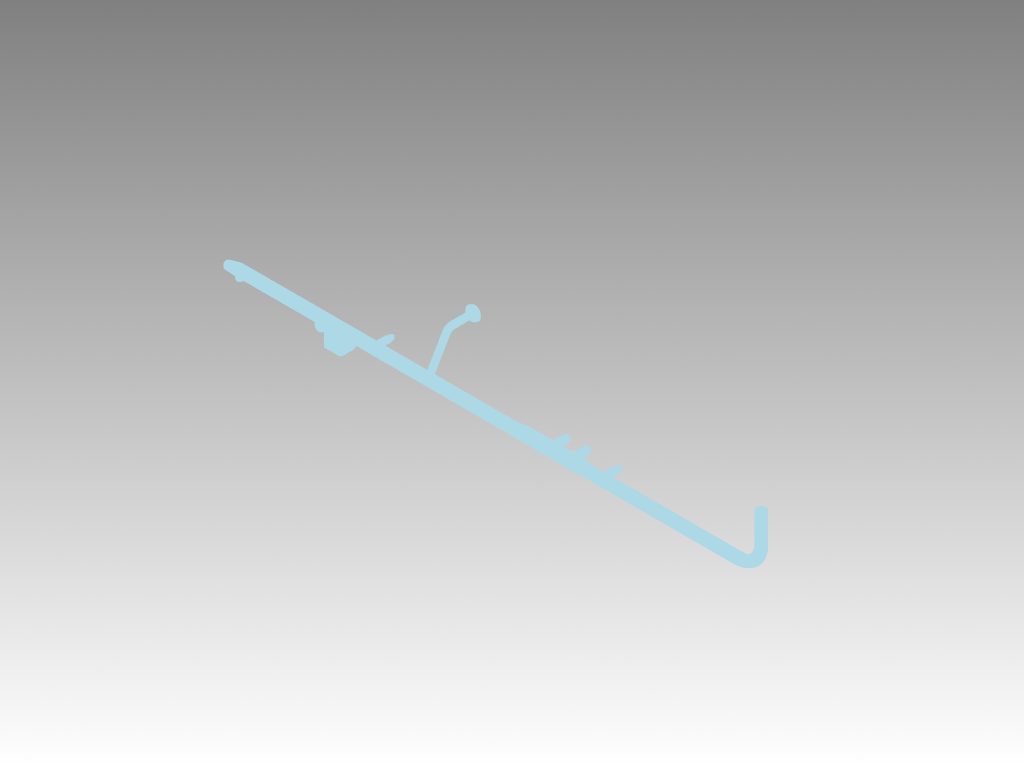

In [18]:
visualize_pointclouds_simply(optimizer._scan_data)

### 1.2. 엔드이펙터 로드

In [19]:
optimizer.load_DDA_from_urdf('./data/robot_models_v1.5/robots/rb10_1300e_DDA.urdf')
dda_mesh = optimizer._EndEffectorPoseOptimizer__dda_mesh # type: ignore
optimizer.load_RT_from_urdf('./data/robot_models_v1.5/robots/rb10_1300e_RT.urdf')
rt_mesh = optimizer._EndEffectorPoseOptimizer__rt_mesh # type: ignore

D:\flame_robotics_drt\python\plugins\poseDeterminator\data\robot_models_v1.5\robots\meshes\link_dda.stl
D:\flame_robotics_drt\python\plugins\poseDeterminator\data\robot_models_v1.5\robots\meshes\link_rt.stl


In [20]:
pl = visualize_mesh(dda_mesh, color='blue') # type: ignore
add_coordinate_frame(pl, length=0.1, size=0.02)

Widget(value='<iframe src="http://localhost:59984/index.html?ui=P_0x1fa8b7824d0_5&reconnect=auto" class="pyvis…

Widget(value='<iframe src="http://localhost:59984/index.html?ui=P_0x1fa8b781300_6&reconnect=auto" class="pyvis…

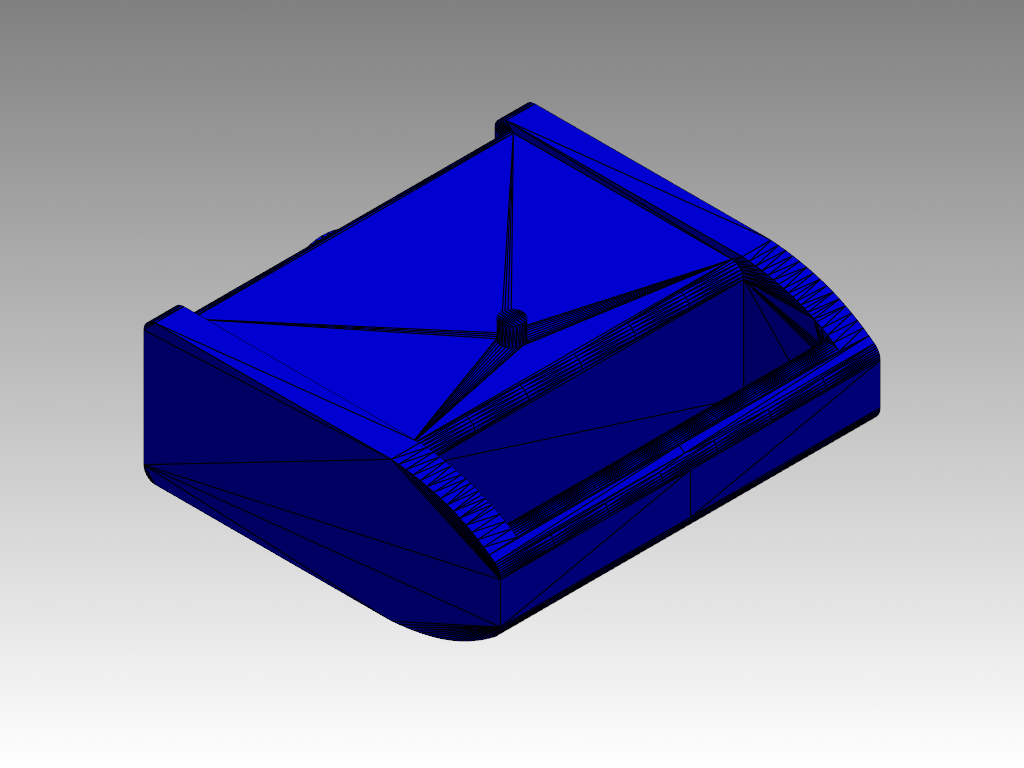

In [21]:
visualize_mesh(rt_mesh, color='blue') # type: ignore

### DDA 가시화

### RT 가시화

# 2. 검사 대상 지점 선택

### 2.1. 배관위 한 점 선택

In [22]:
pl = visualize_selectable_pointcloud(optimizer._scan_data)

Widget(value='<iframe src="http://localhost:59984/index.html?ui=P_0x1fa7b4d35e0_7&reconnect=auto" class="pyvis…

None

Textarea(value='', layout=Layout(height='80px', width='auto'))

### 2.2. 선택된 점 인덱스 저장(수동)

In [23]:
target_point_idx = 303135

### 2.3. 검사 대상 점 가시화

In [24]:
target_point = optimizer._scan_data.points[target_point_idx]

In [25]:
pl = Plotter()
visualize_pointclouds_simply(optimizer._scan_data, plotter=pl)
add_sphere(pl, target_point, radius=0.01, color="red")
pl.show()

Widget(value='<iframe src="http://localhost:59984/index.html?ui=P_0x1fa8bf2a890_8&reconnect=auto" class="pyvis…

# 3. 배관 프로파일 계산

In [26]:
optimizer.calculate_pipe_profile(target_point) # type: ignore

center = optimizer._EndEffectorPoseOptimizer__pipe_center # type: ignore
direction = optimizer._EndEffectorPoseOptimizer__pipe_direction # type: ignore
radius = optimizer._EndEffectorPoseOptimizer__pipe_radius # type: ignore

pl = Plotter()
visualize_pointclouds_simply(optimizer._scan_data, plotter=pl)
pl.add_arrows(center, direction, 0.1, color="red")
add_cylinder(
    pl,
    center,
    direction,
    radius + 0.003,
    0.05,
    "blue",
    0.3,
)
pl.show()

Widget(value='<iframe src="http://localhost:59984/index.html?ui=P_0x1fa8b7805b0_9&reconnect=auto" class="pyvis…

# 4. 엔드이펙터 위치 결정(탐색)

In [27]:
dda_tcp_candidates_filtered_json, dda_tcp_pose_candidates_filtered, dda_tcp_pose_candidates = (
    optimizer.calculate_DDA_pose_for_detecting_welding_point(
        tuple(target_point.tolist()),
        8,
        0.2,
    )
)

### 위치 후보 가시화(화살표만)

In [28]:
arrows= calculate_arrows_from_pose_candidates(dda_tcp_pose_candidates)
pl = visualize_pointclouds_simply(optimizer._scan_data)
_=pl.add_arrows(arrows[..., 0:3], arrows[..., 3:6], 0.1, color="red")

Widget(value='<iframe src="http://localhost:59984/index.html?ui=P_0x1fa827c9a50_10&reconnect=auto" class="pyvi…

In [ ]:
arrows= calculate_arrows_from_pose_candidates(dda_tcp_pose_candidates)
pl = visualize_pointclouds_simply(optimizer._scan_data)
_=pl.add_arrows(arrows[..., 0:3], arrows[..., 3:6], 0.1, color="red")

for dda_tcp_pose in dda_tcp_pose_candidates:
    rot = R.from_euler("xyz", dda_tcp_pose[3:]).as_matrix()
    dda_tcp_pose_T = np.eye(4)
    dda_tcp_pose_T[:3, :3] = rot
    dda_tcp_pose_T[:3,  3] = dda_tcp_pose[:3]

    tcp_to_dda = optimizer._EndEffectorPoseOptimizer__dda_invers_transform_mat # type: ignore
    dda_pose_T = dda_tcp_pose_T @ tcp_to_dda

    add_mesh(pl, dda_mesh, dda_pose_T, color="blue") # type: ignore

In [ ]:
arrows= calculate_arrows_from_pose_candidates(dda_tcp_pose_candidates_filtered)
pl = visualize_pointclouds_simply(optimizer._scan_data)
_=pl.add_arrows(arrows[..., 0:3], arrows[..., 3:6], 0.1, color="red")

for dda_tcp_pose in dda_tcp_pose_candidates_filtered:
    rot = R.from_euler("xyz", dda_tcp_pose[3:]).as_matrix()
    dda_tcp_pose_T = np.eye(4)
    dda_tcp_pose_T[:3, :3] = rot
    dda_tcp_pose_T[:3,  3] = dda_tcp_pose[:3]

    tcp_to_dda = optimizer._EndEffectorPoseOptimizer__dda_invers_transform_mat # type: ignore
    dda_pose_T = dda_tcp_pose_T @ tcp_to_dda

    add_mesh(pl, dda_mesh, dda_pose_T, color="blue") # type: ignore

# 5. 엔드이펙터 위치 결정(검사)

In [ ]:
json_str, dda_poses, rt_poses= optimizer.calculate_DDA_RT_pose_for_taking_xray(
    target_point,
    8,
    0.1,
    0.3,
    10,
)
dda_poses.shape

In [ ]:
IDX = 0

arrows = calculate_arrows_from_pose_candidates(np.vstack([dda_poses[IDX], rt_poses[IDX]]))
pl = visualize_pointclouds_simply(optimizer._scan_data)
_=pl.add_arrows(arrows[..., 0:3], arrows[..., 3:6], 0.05, color="red")

